# Data Cleaning Notebook for Job Data Analysis

This notebook handles the cleaning and preprocessing of raw job data for analysis. It focuses on skills enhancement, date conversion, salary cleaning, and location data standardization.

## 1. Project Setup and Configuration

Configure paths and import necessary libraries and modules.

In [16]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

# Add src to path for custom modules
sys.path.insert(0, '..')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Directory Configuration

Set up data directory paths and ensure they exist.

In [17]:
# Configuration for data paths
DATA_RAW_PATH = Path('../data/raw')
DATA_INTERIM_PATH = Path('../data/interim') 

# Create directories if they don't exist
DATA_RAW_PATH.mkdir(parents=True, exist_ok=True)
DATA_INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"📁 Data directories configured:")
print(f"   Raw: {DATA_RAW_PATH.absolute()}")
print(f"   Interim: {DATA_INTERIM_PATH.absolute()}")

📁 Data directories configured:
   Raw: c:\Users\MARIE\Desktop\PROJECTS\skillhub\notebooks\..\data\raw
   Interim: c:\Users\MARIE\Desktop\PROJECTS\skillhub\notebooks\..\data\interim


## 3. Import Cleaning Modules

Import custom data cleaning modules for job data processing.

In [18]:
# Import the cleaning module
try:
    from src.cleaning.clean_jobs import DataScienceJobsCleaner
    from src.cleaning.clean_job_title import HybridJobTitleClassifier
    from src.cleaning.enhance_skills import SkillEnhancer
    print("✅ Cleaning modules imported successfully!")
except ImportError as e:
    print(f"❌ Error importing cleaning modules: {e}")

✅ Cleaning modules imported successfully!


## 4. Load and Inspect Raw Data

Examine the raw data structure and identify missing values before cleaning.

In [19]:
# Initialize the cleaner
cleaner = DataScienceJobsCleaner()

# Load raw data
raw_df = cleaner.load_raw_data(DATA_RAW_PATH / 'combined_jobs.csv')
print("📊 Raw data sample (first 3 rows):")
display(raw_df.head(3))

# Remove duplicate entries based on key columns
raw_df = raw_df.drop_duplicates(subset=['title','company','location'])

print("\n📝 Raw data info:")
print(f"Shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

print("\n❌ Missing values in raw data:")
missing_raw = raw_df.isnull().sum()
for col, count in missing_raw.items():
    if count > 0:
        pct = (count / len(raw_df)) * 100
        print(f"   {col}: {count} ({pct:.1f}%)")

📊 Raw data sample (first 3 rows):


,title,company,city,country,location,skills,type,salary,salary_min,salary_max,published,slug,ai
0,"Data Scientist, Care Intelligence (All Levels)",Pomelo Care,NaN,NaN,",","Python,SQL,LLMs,Prompt Engineering,Tableau,Dat...",NaN,NaN,0,0,2025-10-14T12:24:11.910081Z,pomelo-care-data-scientist-care-intelligence-a...,True
1,Product Operations Analyst,Bottomline,NaN,NaN,",","SQL,Data Science,Data Analysis,Predictive Mode...",NaN,NaN,0,0,2025-10-14T12:18:05.928506Z,bottomline-product-operations-analyst-xhs6,True
2,Engineering Manager - Integrations & Ecosystems,GWI,Athens,Greece,"Athens, Greece","Backend,LLMs,Cloud,Java,JavaScript,GO,API,CICD...",Full Time,NaN,0,0,2025-10-14T12:11:34.054991Z,gwi-engineering-manager-integrations-and-ecosy...,True



📝 Raw data info:
Shape: (21950, 13)
Columns: ['title', 'company', 'city', 'country', 'location', 'skills', 'type', 'salary', 'salary_min', 'salary_max', 'published', 'slug', 'ai']

❌ Missing values in raw data:
   city: 5202 (23.7%)
   country: 1076 (4.9%)
   type: 132 (0.6%)
   salary: 13433 (61.2%)


## 5. Clean Job Titles

Classify and standardize job titles using the hybrid classification approach.

In [20]:
# Initialize the job title classifier
title_classifier = HybridJobTitleClassifier()

# Clean and classify job titles
cleaned_titles = title_classifier.classify_dataframe(
        raw_df, 
        title_col="title",
        threshold=0.47, 
        batch_size=1000 
    )

# Display the cleaned title data
print("📝 Cleaned job titles sample:")
display(cleaned_titles[["cleaned_title_category", "seniority_level", "similarity_score"]].head(10))

# Analyze title category distribution
print("\n📊 Job title category distribution:")
category_counts = cleaned_titles['cleaned_title_category'].value_counts()
print(category_counts) 

INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-MiniLM-L6-v2


✅ Loading category embeddings from categories.pkl
📝 Cleaned job titles sample:


,cleaned_title_category,seniority_level,similarity_score
0,Data Scientist,Unspecified,0.704747
1,Product Data Scientist,Unspecified,0.686930
2,Other,Manager,0.424553
3,Data Engineer,Unspecified,0.783323
4,Data Science Manager,Manager,0.691720
5,Data Scientist,Unspecified,0.861584
6,Data Engineer,Unspecified,0.642339
7,AI Engineer,Lead,0.827234
8,Data Analyst,Unspecified,0.497805
9,AI Engineer,Unspecified,0.812153



📊 Job title category distribution:
cleaned_title_category
Other                        3852
AI Engineer                  3747
Data Engineer                3459
Data Scientist               2637
Machine Learning Engineer    1928
AI Researcher                1381
Data Analyst                 1177
Product Data Scientist       1075
Data Science Manager          788
Data Architect                682
MLOps Engineer                510
Analytics Engineer            477
Research Scientist            237
Name: count, dtype: int64


## 6. Clean Skills Data

Enhance and standardize the skills data for better analysis.

In [21]:
# Initialize skill enhancer and process skills data
skill_enhancer = SkillEnhancer()
cleaned_skills = skill_enhancer.enhance_skills_data(cleaned_titles)

# Display the enhanced skills data
print("Enhanced skills data sample:")
cleaned_skills[['skills','skills_count']].head(2)

INFO:src.cleaning.enhance_skills:✅ Skills data enhanced


Enhanced skills data sample:


,skills,skills_count
0,"[Prompt Engineering, Airflow, Quantitative, Pr...",12
1,"[Power Bi, Predictive Modelling, Json, Sql, Se...",8


## 7. Clean Date Data

Convert published dates to proper datetime format and extract temporal features.

In [22]:
# Convert date columns to proper datetime format
cleaned_date = cleaner.convert_dates(cleaned_skills)

# Display the cleaned date data
print("Cleaned date data sample:")
cleaned_date[['published','date']].head(2)

INFO:src.cleaning.clean_jobs:✅ Date data converted


Cleaned date data sample:


,published,date
0,2025-10-14 12:24:11.910081+00:00,2025.0_10.0
1,2025-10-14 12:18:05.928506+00:00,2025.0_10.0


## 8. Clean Salary Data

Standardize salary information and convert to USD for consistent analysis.

In [23]:
# Clean and standardize salary data
cleaned_salary = cleaner.clean_salary_data(cleaned_date)

# Display the cleaned salary data
print("Cleaned salary data sample:")
cleaned_salary[['salary_min_usd','salary_max_usd','salary_category']].tail(5)

INFO:src.cleaning.clean_jobs:✅ Salary data cleaned. 7806/21950 valid salaries found.


Cleaned salary data sample:


,salary_min_usd,salary_max_usd,salary_category
29801,275000.0,300000.0,Very High (250k-500k)
29802,NaN,NaN,Unknown
29803,275000.0,300000.0,Very High (250k-500k)
29804,NaN,NaN,Unknown
29805,180000.0,300000.0,High (150k-250k)


In [24]:
cleaned_salary[cleaned_salary['avg_salary_usd'].notnull()].head()

,title,company,city,country,location,skills,type,salary,salary_min,salary_max,...,similarity_score,skills_count,published_year,published_month,date,salary_min_usd,salary_max_usd,avg_salary_usd,salary_type,salary_category
3,"Data Engineer II (Remote, US)",Openly,NaN,USA,", USA","[Airflow, Go, Datadog, Bigquery, Jupyter Noteb...","Remote,Full Time","$108,000-$162,000 annually",108000.0,162000.0,...,0.783323,26,2025.0,10.0,2025.0_10.0,108000.0,162000.0,135000.0,annual,Medium-High (100k-150k)
4,Data Strategy Manager,Avalere Health,"New York, NY",USA,"New York, NY, USA","[S3, Looker, Project Management, Tableau, Goog...",Full Time,"$75,000-$105,000 annually",75000.0,105000.0,...,0.691720,5,2025.0,10.0,2025.0_10.0,75000.0,105000.0,90000.0,annual,Medium (60k-100k)
7,Staff AI Engineer,IMO Health,"Houston, TX",USA,"Houston, TX, USA","[S3, Automation, Huggingface, Azure, Embedding...",Full Time,$180000-$250000 annually,180000.0,250000.0,...,0.827234,33,2025.0,10.0,2025.0_10.0,180000.0,250000.0,215000.0,annual,High (150k-250k)
9,AI Architect,Bounteous,NaN,USA,", USA","[S3, Huggingface, Azure, Transformation, Relia...","Remote,Full Time","$165,000-$185,000 annually",165000.0,185000.0,...,0.812153,26,2025.0,10.0,2025.0_10.0,165000.0,185000.0,175000.0,annual,High (150k-250k)
10,"Senior Product Manager, Search &amp; Recommend...",Quizlet,"San Francisco, CA",USA,"San Francisco, CA, USA","[S3, Sme, Product Management, Agile, Product D...","Full Time,Onsite","$155,000-$195,000 annually",155000.0,195000.0,...,0.474226,11,2025.0,10.0,2025.0_10.0,155000.0,195000.0,175000.0,annual,High (150k-250k)


In [25]:
zero_salary_data = cleaned_salary[cleaned_salary['avg_salary_usd']==15000]
display(zero_salary_data.head(2),zero_salary_data.shape)

,title,company,city,country,location,skills,type,salary,salary_min,salary_max,...,similarity_score,skills_count,published_year,published_month,date,salary_min_usd,salary_max_usd,avg_salary_usd,salary_type,salary_category


(0, 25)

In [26]:
cleaned_salary[['salary_min_usd', 'salary_max_usd']] = cleaned_salary[['salary_min_usd', 'salary_max_usd']].replace(0, np.nan)
cleaned_salary[cleaned_salary['salary_min_usd']<=1000].tail(10)
cleaned_salary[['salary_min_usd', 'salary_max_usd']] = np.where(cleaned_salary[['salary_min_usd', 'salary_max_usd']] < 1000, np.nan, cleaned_salary[['salary_min_usd', 'salary_max_usd']])

In [27]:
cleaned_salary[['salary_min_usd', 'salary_max_usd','avg_salary_usd']].describe()    

,salary_min_usd,salary_max_usd,avg_salary_usd
count,7806.000000,7806.000000,7806.000000
mean,140254.230701,205933.049653,173093.640177
std,53861.682144,75633.514948,61363.115597
min,3344.000000,3344.000000,3344.000000
25%,100000.000000,160000.000000,132412.500000
50%,136000.000000,202750.000000,170000.000000
75%,173000.000000,249800.000000,209000.000000
max,497006.400000,745509.600000,621258.000000


In [28]:
cleaned_salary[cleaned_salary['avg_salary_usd']>1000000]

,title,company,city,country,location,skills,type,salary,salary_min,salary_max,...,similarity_score,skills_count,published_year,published_month,date,salary_min_usd,salary_max_usd,avg_salary_usd,salary_type,salary_category


## 9. Visualize Salary Distribution

Create visualizations to understand the distribution of cleaned salary ranges.

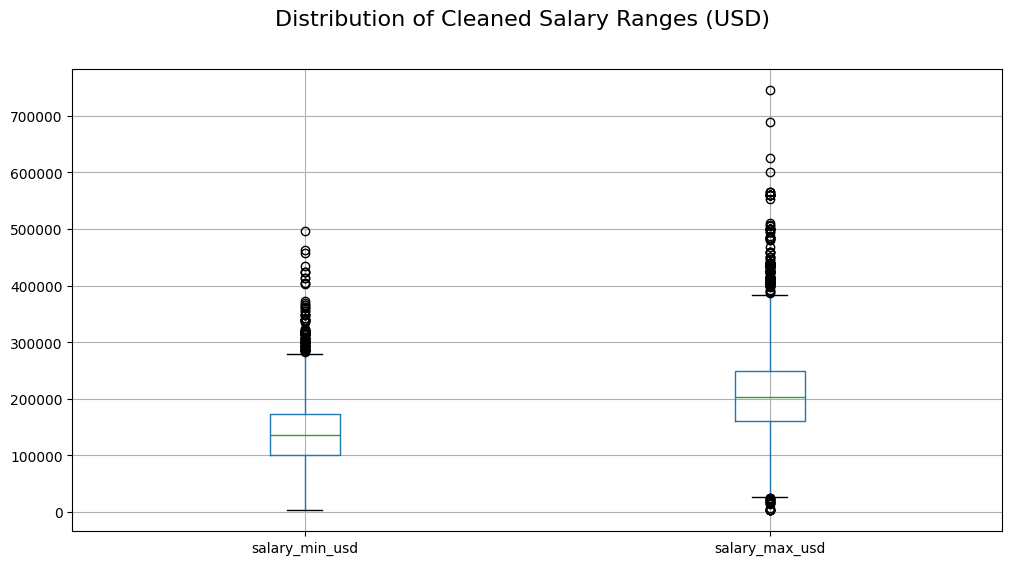

In [29]:
# Create boxplot for salary distribution analysis
cleaned_salary[['salary_min_usd','salary_max_usd']].boxplot(figsize=(12,6))
plt.suptitle('Distribution of Cleaned Salary Ranges (USD)', fontsize=16)
plt.show()

### 10. Clean Job Type 
Standardize Job type information (Remote, Fulltime, etc).

In [30]:
cleaned_job_type = cleaner.clean_job_type(cleaned_salary)
cleaned_job_type[['cleaned_job_type','job_type','work_mode']].head(5)

INFO:src.cleaning.clean_jobs:✅ Job types cleaned.


,cleaned_job_type,job_type,work_mode
0,[unknown],NaN,NaN
1,[unknown],NaN,NaN
2,[full time],full_time,NaN
3,"[remote,full time]",full_time,remote
4,[full time],full_time,NaN


### 11. Clean Country/Location Data

Standardize country and location information for geographical analysis.

In [31]:
# Clean and standardize location data
cleaned_country = cleaner.clean_location_data(cleaned_job_type)

# Display the cleaned location data
print("Cleaned location data sample:")
cleaned_country[['country']].head(5)

INFO:src.cleaning.clean_jobs:✅ Location data cleaned


Cleaned location data sample:


,country
0,Unknown
1,Unknown
2,Greece
3,USA
4,USA


### 12. Analyze Data Distributions

Examine distributions across different dimensions after cleaning.

🌍 Country distribution in cleaned data:
country
USA               10579
India              2169
Unknown            1077
France              837
United Kingdom      771
Canada              723
Germany             573
Poland              456
Spain               290
Portugal            262
Name: count, dtype: int64

📊 Title category distribution:
cleaned_title_category
Other                        3852
AI Engineer                  3747
Data Engineer                3459
Data Scientist               2637
Machine Learning Engineer    1928
AI Researcher                1381
Data Analyst                 1177
Product Data Scientist       1075
Data Science Manager          788
Data Architect                682
MLOps Engineer                510
Analytics Engineer            477
Research Scientist            237
Name: count, dtype: int64


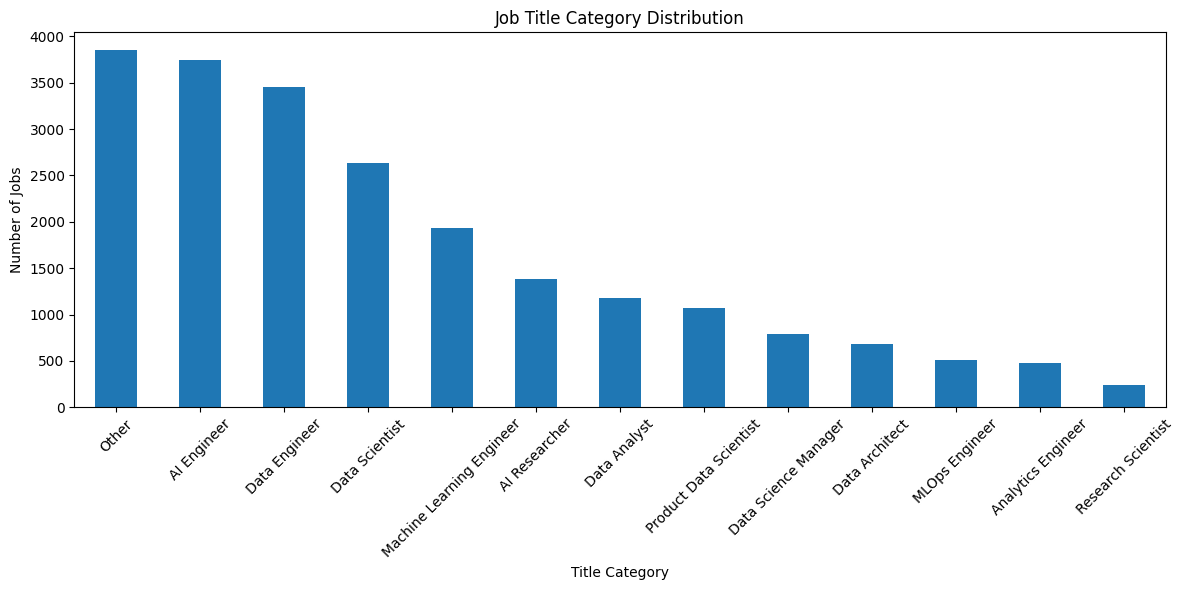

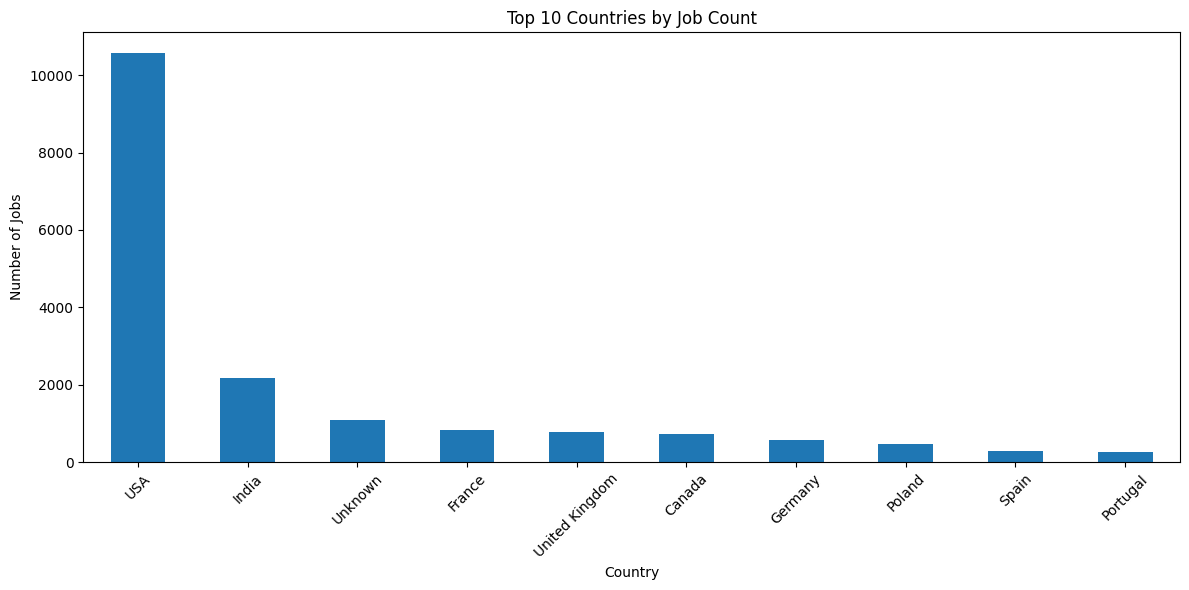

In [32]:
# Analyze country distribution
country_counts = cleaned_country['country'].value_counts()
print("🌍 Country distribution in cleaned data:")
print(country_counts.head(10))

# Analyze title category distribution
title_category_counts = cleaned_country['cleaned_title_category'].value_counts()
print("\n📊 Title category distribution:")
print(title_category_counts)

# Create visualization for title categories
plt.figure(figsize=(12, 6))
title_category_counts.plot(kind='bar')
plt.title('Job Title Category Distribution')
plt.xlabel('Title Category')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create visualization for top countries
plt.figure(figsize=(12, 6))
country_counts.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Job Count')
plt.xlabel('Country')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 13. Final Data Quality Check

Perform comprehensive data quality assessment on the fully cleaned dataset.

In [33]:
print("Final Data Quality Assessment:")
print(f"Final dataset shape: {cleaned_country.shape}")
print(f"Final columns: {list(cleaned_country.columns)}")

print("\n Final missing values analysis:")
missing_final = cleaned_country.isnull().sum()
for col, count in missing_final.items():
    if count > 0:
        pct = (count / len(cleaned_country)) * 100
        print(f"   {col}: {count} ({pct:.1f}%)")

print(f"\n Salary data availability:")
salary_available = cleaned_country['salary_category'] != 'Unknown'
print(f"Jobs with salary information: {salary_available.sum()} ({(salary_available.sum() / len(cleaned_country)) * 100:.1f}%)")

print(f"\n Location data completeness:")
location_complete = cleaned_country['country'] != 'Unknown'
print(f"Jobs with country information: {location_complete.sum()} ({(location_complete.sum() / len(cleaned_country)) * 100:.1f}%)")

print(f"\n Title classification coverage:")
title_classified = cleaned_country['cleaned_title_category'].notna()
print(f"Jobs with title classification: {title_classified.sum()} ({(title_classified.sum() / len(cleaned_country)) * 100:.1f}%)")

Final Data Quality Assessment:
Final dataset shape: (21950, 29)
Final columns: ['title', 'company', 'city', 'country', 'location', 'skills', 'type', 'salary', 'salary_min', 'salary_max', 'published', 'slug', 'ai', 'cleaned_title_category', 'seniority_level', 'similarity_score', 'skills_count', 'published_year', 'published_month', 'date', 'salary_min_usd', 'salary_max_usd', 'avg_salary_usd', 'salary_type', 'salary_category', 'job_type', 'work_mode', 'is_intern', 'cleaned_job_type']

 Final missing values analysis:
   city: 5202 (23.7%)
   type: 132 (0.6%)
   salary: 13433 (61.2%)
   salary_min: 13563 (61.8%)
   salary_max: 13560 (61.8%)
   published: 15 (0.1%)
   published_year: 15 (0.1%)
   published_month: 15 (0.1%)
   salary_min_usd: 14144 (64.4%)
   salary_max_usd: 14144 (64.4%)
   avg_salary_usd: 14144 (64.4%)
   job_type: 2248 (10.2%)
   work_mode: 16520 (75.3%)

 Salary data availability:
Jobs with salary information: 7807 (35.6%)

 Location data completeness:
Jobs with country i

## 13. Save Cleaned Data

Save the fully processed dataset for future analysis and modeling.

In [34]:
# Save the cleaned dataset
output_file = DATA_INTERIM_PATH / 'cleaned_jobs_data.csv'
cols_to_save = ['country', 'company', 'cleaned_title_category', 'seniority_level', 'skills',
                'date','salary_category', 'avg_salary_usd', 'job_type','work_mode', 'skills_count']

cleaned_country[['job_type','work_mode']] = cleaned_country[['job_type','work_mode']].fillna('Not Specified')
cleaned_country['date'].replace('nan_nan', np.nan, inplace=True)
cleaned_country.dropna(subset=['date'], inplace=True)
cleaned_country = cleaned_country[cleaned_country['cleaned_title_category'] != 'Other'].reset_index(drop=True)

cleaned_country[cols_to_save].to_csv(output_file, index=False)
print(f"💾 Cleaned data saved to: {output_file}")

print(f"\n✅ Data cleaning pipeline completed successfully!")
print(f"   Original records: {len(raw_df)}")
print(f"   Final cleaned records: {len(cleaned_country)}")
print(f"   Data reduction: {((len(raw_df) - len(cleaned_country)) / len(raw_df)) * 100:.1f}%")

print(f"\n🎯 Key enhancements applied:")
print(f"   - Title cleaning and categorization")
print(f"   - Skills standardization and counting")
print(f"   - Date formatting and feature extraction")
print(f"   - Salary normalization and categorization")
print(f"   - Location and country standardization")

💾 Cleaned data saved to: ..\data\interim\cleaned_jobs_data.csv

✅ Data cleaning pipeline completed successfully!
   Original records: 21950
   Final cleaned records: 18088
   Data reduction: 17.6%

🎯 Key enhancements applied:
   - Title cleaning and categorization
   - Skills standardization and counting
   - Date formatting and feature extraction
   - Salary normalization and categorization
   - Location and country standardization


## Summary

This notebook systematically processes raw job data through multiple cleaning stages:

### Data Processing Pipeline:
1. **Title Classification** - Cleaned and categorized job titles using hybrid classification approach
2. **Skills Enhancement** - Standardized and enriched skills data with skill counts
3. **Date Conversion** - Converted published dates to datetime format and extracted temporal features
4. **Salary Cleaning** - Normalized salary data to USD and categorized salary ranges
5. **Location Standardization** - Cleaned and standardized country and location information
6. **Data Quality Assessment** - Comprehensive validation of data completeness and quality

### Key Outcomes:
- Removed duplicate entries based on title, company, and location
- Classified job titles into standardized categories for better analysis
- Enhanced skills data with standardized formatting and counts
- Normalized salary information for consistent analysis
- Standardized geographical data for location-based insights
- Preserved data integrity throughout the cleaning process

The cleaned dataset is now ready for exploratory data analysis, feature engineering, and machine learning modeling with properly classified job titles and standardized features.